# 319 Phase 3 — XGBoost lv4_aggressive 통합 학습 + chan held-out 평가

**참조**:
- Phase 1: `services/ai/train/model_experiment/xgboost_gyeom_final_pool.ipynb` (보존, read-only)
- Phase 2: `services/ai/train/model_experiment/xgboost_gyeom_phase2_external.ipynb` (chan 324 baseline)

## 본 phase scope

학습 풀에 **lv4_aggressive 101 trials** 추가 (압도적 매크로 — 직선 + fixed 5ms timing + 노이즈 0). variable 1개만 변경:
- 기존 final_pool: cv_pool 601 (balabit 500 + lv2_macro 101)
- 본 phase: cv_pool 702 (+ lv4_aggressive 101)
- held-out / eval / hyperparameter / feature / random_state=42 = Phase 1 그대로

## 진단 갱신 (2026-05-08)

chan AUC 0.50 원인 = **학습 풀 macro spectrum 한쪽 끝 (압도적 매크로) 부재**. lv2_bezier (약간 매크로) + lv3_kde (사람 유사) 만 있어서 chan 같은 압도적 매크로는 OOD. lv4_aggressive 추가로 spectrum 광범위 cover.

기대: m4.1 overshadow 완화 + chan held-out AUC > 0.5000 (Phase 2 §2 baseline 초과) + allow_FN_op < 1.0000.

## Decision lock 요약

- #1 collector: 보겸 algorithm 설계 + lv4_collector.py (직선 + 5ms STEP_TIME + DELAY=0 + 화면 자동 SAFE)
- #2 데이터 수집: 보겸 자체 작업, 101 trials (1 outlier `bfa48fdbcc06` 50ms 버전 분리됨)
- #3 적재: `services/ai/data/behavior/`, trial_id 940001~940101, group `lv4_aggressive`
- #4 학습: variable 1개만 변경 (lv4 추가), Phase 1 hyperparameter / feature / seed 그대로
- #5 chan eval: §9 추가 (Phase 2 §1+§2 패턴 reuse)


## 1. 데이터 준비

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

SEED = 42
MODEL_NAME = "xgboost_gyeom_phase3_lv4_integrated"
LABEL_MAPPING = {"human": 0, "macro": 1}

ROOT = Path.cwd()
if ROOT.name != "model_experiment":
    raise Exception(f"작업 디렉토리는 model_experiment 여야 함 (현재: {ROOT.name})")

CONFIG_PATH = Path("../../configs/feature_config.yaml")
DATA_DIR = Path("../../data/behavior")
MODEL_DIR = Path("../model_joblib") / MODEL_NAME

# trial_id ranges (services/ai/train/EDA/trial_loader.py 동일)
LV2_RANGE = (900001, 909999)
BALABIT_RANGE = (910001, 910500)
LV3_BALABIT_KDE_RANGE = (930001, 930050)
LV4_AGGRESSIVE_RANGE = (940001, 949999)

print("ROOT:", ROOT)
print("CONFIG_PATH:", CONFIG_PATH)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)


ROOT: c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_experiment
CONFIG_PATH: ..\..\configs\feature_config.yaml
DATA_DIR: ..\..\data\behavior
MODEL_DIR: ..\model_joblib\xgboost_gyeom_phase3_lv4_integrated


In [2]:
# yaml 로드 — 319 final pool 2 features
with CONFIG_PATH.open("r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

INPUT_FEATURES = feature_config["input_features_gyeom_final_pool"]
FEATURE_NAME_KO = feature_config.get("names_ko", {})
print(f"INPUT_FEATURES (final pool): {INPUT_FEATURES}")

# trial_id range → trial_group 매핑
def trial_group(trial_id):
    if LV2_RANGE[0] <= trial_id <= LV2_RANGE[1]:
        return "lv2"
    if BALABIT_RANGE[0] <= trial_id <= BALABIT_RANGE[1]:
        return "balabit"
    if LV3_BALABIT_KDE_RANGE[0] <= trial_id <= LV3_BALABIT_KDE_RANGE[1]:
        return "lv3_balabit_kde"
    if LV4_AGGRESSIVE_RANGE[0] <= trial_id <= LV4_AGGRESSIVE_RANGE[1]:
        return "lv4_aggressive"
    return None

# Balabit user_id 추출 (StratifiedGroupKFold groups param용)
_BALABIT_USER_RE = re.compile(r"^balabit_(user\d+)_")
def parse_balabit_user(session_id):
    if not session_id:
        return None
    m = _BALABIT_USER_RE.match(session_id)
    return m.group(1) if m else None

def load_all_trials(data_dir):
    rows = []
    counters = {"total": 0, "kept": 0, "no_label": 0, "out_of_range": 0}

    for path in sorted(data_dir.glob("trial_*.json")):
        counters["total"] += 1
        try:
            trial_id = int(path.stem.split("_", 1)[1])
        except (IndexError, ValueError):
            continue

        group = trial_group(trial_id)
        if group is None:
            counters["out_of_range"] += 1
            continue

        payload = json.loads(path.read_text(encoding="utf-8"))
        label = payload.get("label")
        if label not in LABEL_MAPPING:
            counters["no_label"] += 1
            continue

        summary = payload.get("summary") or {}
        metrics = payload.get("metrics") or {}
        row = {
            "trial_id": trial_id,
            "label": label,
            "trial_group": group,
            "session_id": summary.get("session_id"),
            "top_user_id": payload.get("user_id"),
        }
        row.update(metrics)
        rows.append(row)
        counters["kept"] += 1

    df = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)

    # lv2 세분화: lv2_human / lv2_macro
    df.loc[(df["trial_group"] == "lv2") & (df["label"] == "human"), "trial_group"] = "lv2_human"
    df.loc[(df["trial_group"] == "lv2") & (df["label"] == "macro"), "trial_group"] = "lv2_macro"

    # balabit user_id (group_id parameter용)
    df["balabit_user_id"] = df["session_id"].apply(parse_balabit_user)

    print(f"load counters: {counters}")
    return df

df = load_all_trials(DATA_DIR)
display(df["trial_group"].value_counts().rename_axis("trial_group").reset_index(name="count"))
print(f"total trials: {len(df)}")

# 3-pool 분리 (결정 #1 + #3)
cv_pool = df[df["trial_group"].isin(["lv2_macro", "balabit", "lv4_aggressive"])].reset_index(drop=True)
holdout_lv3 = df[df["trial_group"] == "lv3_balabit_kde"].reset_index(drop=True)
eval_lv2_human = df[df["trial_group"] == "lv2_human"].reset_index(drop=True)

print(f"\ncv_pool: {len(cv_pool)} (target 702)")
print(f"  lv2_macro:      {(cv_pool['trial_group'] == 'lv2_macro').sum()} (target 101)")
print(f"  balabit:        {(cv_pool['trial_group'] == 'balabit').sum()} (target 500)")
print(f"  lv4_aggressive: {(cv_pool['trial_group'] == 'lv4_aggressive').sum()} (target 101)")
print(f"holdout_lv3: {len(holdout_lv3)} (target 50)")
print(f"eval_lv2_human: {len(eval_lv2_human)} (target 51)")

assert len(cv_pool) == 702, f"cv_pool size mismatch: {len(cv_pool)} != 702"
assert len(holdout_lv3) == 50, f"holdout_lv3 size mismatch: {len(holdout_lv3)} != 50"
assert len(eval_lv2_human) == 51, f"eval_lv2_human size mismatch: {len(eval_lv2_human)} != 51"
print("\n모든 풀 카운트 검증 통과")


INPUT_FEATURES (final pool): ['mouse_jerk_mean', 'mouse_max_speed_px_per_ms']
load counters: {'total': 803, 'kept': 803, 'no_label': 0, 'out_of_range': 0}


,trial_group,count
0,balabit,500
1,lv2_macro,101
2,lv4_aggressive,101
3,lv2_human,51
4,lv3_balabit_kde,50


total trials: 803

cv_pool: 702 (target 702)
  lv2_macro:      101 (target 101)
  balabit:        500 (target 500)
  lv4_aggressive: 101 (target 101)
holdout_lv3: 50 (target 50)
eval_lv2_human: 51 (target 51)

모든 풀 카운트 검증 통과


## 2. 데이터 전처리

In [3]:
present_features = [f for f in INPUT_FEATURES if f in df.columns]
missing_features = [f for f in INPUT_FEATURES if f not in df.columns]
print(f"present: {present_features}")
print(f"missing: {missing_features}")

if missing_features:
    raise ValueError(f"필수 features 누락: {missing_features}")

def make_X_y(pool_df):
    X = pool_df[present_features].apply(pd.to_numeric, errors="coerce")
    y = pool_df["label"].map(LABEL_MAPPING).astype(int).to_numpy()
    return X, y

X_cv, y_cv = make_X_y(cv_pool)
X_lv3, y_lv3 = make_X_y(holdout_lv3)
X_lv2h, y_lv2h = make_X_y(eval_lv2_human)

print(f"\nX_cv shape: {X_cv.shape}, y_cv class counts: {dict(zip(*np.unique(y_cv, return_counts=True)))}")
print(f"X_lv3 shape: {X_lv3.shape}, y_lv3 class counts: {dict(zip(*np.unique(y_lv3, return_counts=True)))}")
print(f"X_lv2h shape: {X_lv2h.shape}, y_lv2h class counts: {dict(zip(*np.unique(y_lv2h, return_counts=True)))}")

# NaN 검증 — memory feedback_missing_data_policy: 즉시 정지·보고
for name, X in [("X_cv", X_cv), ("X_lv3", X_lv3), ("X_lv2h", X_lv2h)]:
    nan_count = int(X.isna().sum().sum())
    if nan_count > 0:
        nan_per_feat = X.isna().sum().to_dict()
        raise ValueError(f"{name} NaN 발견 ({nan_count}개): {nan_per_feat} — 정지·보고 필요")
print("\n모든 풀 NaN 0건 검증 통과")


present: ['mouse_jerk_mean', 'mouse_max_speed_px_per_ms']
missing: []

X_cv shape: (702, 2), y_cv class counts: {0: 500, 1: 202}
X_lv3 shape: (50, 2), y_lv3 class counts: {1: 50}
X_lv2h shape: (51, 2), y_lv2h class counts: {0: 51}

모든 풀 NaN 0건 검증 통과


## 3. 모델 준비

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

SCALE_POS_WEIGHT = 4.95  # human 500 / macro 101 (#3/#4 합의값, 전체 cv_pool 고정)

def build_model(seed=SEED):
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                XGBClassifier(
                    n_estimators=400,
                    max_depth=3,
                    learning_rate=0.03,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    scale_pos_weight=SCALE_POS_WEIGHT,
                    tree_method="hist",
                    random_state=seed,
                    n_jobs=-1,
                ),
            ),
        ]
    )

model = build_model(SEED)
print(f"scale_pos_weight: {SCALE_POS_WEIGHT}")
print(f"INPUT_FEATURES: {INPUT_FEATURES}")
print("hyperparam: n_estimators=400, max_depth=3, lr=0.03, subsample=0.9, colsample_bytree=0.9")
model


scale_pos_weight: 4.95
INPUT_FEATURES: ['mouse_jerk_mean', 'mouse_max_speed_px_per_ms']
hyperparam: n_estimators=400, max_depth=3, lr=0.03, subsample=0.9, colsample_bytree=0.9


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

## 4. 모델 학습 + 5-fold CV (§5a)

601 trials cv_pool에서 `StratifiedGroupKFold(n_splits=5)` 학습 + 평가.

- **Group 정의** (m3.6 hybrid): balabit `user_id` 10 groups + lv2_macro singleton-per-trial 101 (분산 효과)
- **Primary**: ROC AUC
- **Secondary 5**: `block_FP_rate` / `allow_FN_rate_design` (≤0.40) / `allow_FN_rate_operational` (≤0.001) / `review_rate_design` / `review_rate_operational`
- **Tertiary**: F1, accuracy, precision@0.75 (OOF), recall@0.40 (OOF)
- **m5.2 caveat**: 320-B baseline (random split + LogReg 단일 feature) 직접 비교 X. floor reference 0.81


In [5]:
from sklearn.metrics import (
    make_scorer,
    f1_score,
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
)


# P(macro) >= block_threshold인 human 비율 (peak time FP cost)
def block_fp_rate(y_true, y_proba, block_threshold=0.75):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    is_human = (y_true == 0)
    if is_human.sum() == 0:
        return float("nan")
    return float(((y_proba >= block_threshold) & is_human).sum() / is_human.sum())


# P(macro) <= allow_threshold인 macro 비율 (scalper 통과 cost)
def allow_fn_rate(y_true, y_proba, allow_threshold):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    is_macro = (y_true == 1)
    if is_macro.sum() == 0:
        return float("nan")
    return float(((y_proba <= allow_threshold) & is_macro).sum() / is_macro.sum())


# allow_threshold < P(macro) < block_threshold 비율 (DL secondary 부하)
def review_rate(y_true, y_proba, allow_threshold, block_threshold=0.75):
    y_proba = np.asarray(y_proba)
    return float(((y_proba > allow_threshold) & (y_proba < block_threshold)).sum() / len(y_proba))


# 3-tier scoring dict (sklearn 1.8 modern API: response_method='predict_proba')
SCORING = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "block_FP_rate": make_scorer(
        lambda yt, yp: block_fp_rate(yt, yp, 0.75),
        response_method="predict_proba",
    ),
    "allow_FN_rate_design": make_scorer(
        lambda yt, yp: allow_fn_rate(yt, yp, 0.40),
        response_method="predict_proba",
    ),
    "allow_FN_rate_operational": make_scorer(
        lambda yt, yp: allow_fn_rate(yt, yp, 0.001),
        response_method="predict_proba",
    ),
    "review_rate_design": make_scorer(
        lambda yt, yp: review_rate(yt, yp, 0.40, 0.75),
        response_method="predict_proba",
    ),
    "review_rate_operational": make_scorer(
        lambda yt, yp: review_rate(yt, yp, 0.001, 0.75),
        response_method="predict_proba",
    ),
}

print(f"총 {len(SCORING)}개 metrics:")
print("  primary: roc_auc")
print("  secondary 5: block_FP_rate, allow_FN_rate_(design/operational), review_rate_(design/operational)")
print("  tertiary 4: f1, accuracy, precision, recall")


총 10개 metrics:
  primary: roc_auc
  secondary 5: block_FP_rate, allow_FN_rate_(design/operational), review_rate_(design/operational)
  tertiary 4: f1, accuracy, precision, recall


In [6]:
from sklearn.model_selection import StratifiedGroupKFold

# m3.6 Hybrid groups vector:
# - balabit: groups[i] = balabit_user_id (10 unique groups, 각 50 trials)
# - lv2_macro: groups[i] = f"lv2_macro_{trial_id}" (각 trial unique singleton group)

def make_groups(pool_df):
    groups = []
    for _, row in pool_df.iterrows():
        if row["trial_group"] == "balabit":
            uid = row["balabit_user_id"]
            if not uid:
                raise ValueError(f"balabit trial_id={row['trial_id']} has no user_id")
            groups.append(uid)
        elif row["trial_group"] == "lv2_macro":
            groups.append(f"lv2_macro_{row['trial_id']}")
        elif row["trial_group"] == "lv4_aggressive":
            groups.append(f"lv4_{row['trial_id']}")
        else:
            raise ValueError(f"unexpected trial_group {row['trial_group']!r} in cv_pool")
    return np.array(groups)


groups_cv = make_groups(cv_pool)
n_lv2_macro_groups = len(np.unique([g for g in groups_cv if g.startswith("lv2_macro_")]))
n_lv4_groups = len(np.unique([g for g in groups_cv if g.startswith("lv4_")]))
n_balabit_groups = len(np.unique([g for g in groups_cv if not (g.startswith("lv2_macro_") or g.startswith("lv4_"))]))
print(f"groups_cv shape: {groups_cv.shape}")
print(f"unique groups: {len(np.unique(groups_cv))}")
print(f"  balabit (user_id): {n_balabit_groups}")
print(f"  lv2_macro (singleton): {n_lv2_macro_groups}")
print(f"  lv4_aggressive (singleton): {n_lv4_groups}")

assert n_balabit_groups == 10, f"balabit groups {n_balabit_groups} != 10"
assert n_lv2_macro_groups == 101, f"lv2_macro singleton groups {n_lv2_macro_groups} != 101"
assert n_lv4_groups == 101, f"lv4_aggressive singleton groups {n_lv4_groups} != 101"

# StratifiedGroupKFold split + fold별 카운트 assertion
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_stats = []
for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X_cv, y_cv, groups=groups_cv)):
    test_pool = cv_pool.iloc[test_idx]
    n_lv2_macro = (test_pool["trial_group"] == "lv2_macro").sum()
    n_balabit = (test_pool["trial_group"] == "balabit").sum()
    n_lv4 = (test_pool["trial_group"] == "lv4_aggressive").sum()
    n_balabit_users = test_pool[test_pool["trial_group"] == "balabit"]["balabit_user_id"].nunique()
    fold_stats.append({
        "fold": fold_idx,
        "test_size": len(test_idx),
        "test_lv2_macro": int(n_lv2_macro),
        "test_balabit": int(n_balabit),
        "test_lv4_aggressive": int(n_lv4),
        "test_balabit_users": int(n_balabit_users),
    })

display(pd.DataFrame(fold_stats))

# 각 fold ~20 lv2_macro + ~100 balabit (2 user-groups). 허용 범위 넓게.
for stat in fold_stats:
    total_macro = stat["test_lv2_macro"] + stat["test_lv4_aggressive"]
    assert 20 <= total_macro <= 60, f"fold {stat['fold']} macro (lv2+lv4) count {total_macro} out of [20,60]"
    assert 50 <= stat["test_balabit"] <= 150, f"fold {stat['fold']} balabit count {stat['test_balabit']} out of [50,150]"
    assert 1 <= stat["test_balabit_users"] <= 3, f"fold {stat['fold']} balabit_users {stat['test_balabit_users']} unexpected"
print("\nfold별 카운트 assertion 통과")


groups_cv shape: (702,)
unique groups: 212
  balabit (user_id): 10
  lv2_macro (singleton): 101
  lv4_aggressive (singleton): 101


,fold,test_size,test_lv2_macro,test_balabit,test_lv4_aggressive,test_balabit_users
0,0,141,19,100,22,2
1,1,141,26,100,15,2
2,2,140,19,100,21,2
3,3,140,17,100,23,2
4,4,140,20,100,20,2



fold별 카운트 assertion 통과


In [7]:
from sklearn.model_selection import cross_validate
import time

start = time.time()
cv_result = cross_validate(
    build_model(SEED),
    X_cv,
    y_cv,
    cv=list(sgkf.split(X_cv, y_cv, groups=groups_cv)),
    scoring=SCORING,
    n_jobs=-1,
    return_train_score=False,
)
elapsed = time.time() - start
print(f"cross_validate elapsed: {elapsed:.2f}s")

cv_summary = pd.DataFrame([
    {
        "metric": metric.replace("test_", ""),
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
        "min": float(values.min()),
        "max": float(values.max()),
    }
    for metric, values in cv_result.items()
    if metric.startswith("test_")
]).sort_values("metric").reset_index(drop=True)

display(cv_summary)

# AUC 0.81 floor 검증 (m5.2 caveat: floor reference, regression target X)
auc_mean = float(cv_summary[cv_summary["metric"] == "roc_auc"]["mean"].iloc[0])
auc_std = float(cv_summary[cv_summary["metric"] == "roc_auc"]["std"].iloc[0])
print(f"\n=== AUC 0.81 floor check (m5.2 caveat applied) ===")
print(f"5-fold CV ROC AUC: mean={auc_mean:.4f}, std={auc_std:.4f}")
print(f"  vs 320-B floor (jerk_mean lv3 AUC 0.81): {'>=' if auc_mean >= 0.81 else '<'} floor")
print(f"  vs target 0.85: {'>=' if auc_mean >= 0.85 else '<'} target")
print(f"  vs std target 0.05: {'OK' if auc_std < 0.05 else 'FLAG'}")


cross_validate elapsed: 6.20s


,metric,mean,std,min,max
0,accuracy,0.981469,0.008149,0.971429,0.992908
1,allow_FN_rate_design,0.019878,0.020882,0.000000,0.050000
2,allow_FN_rate_operational,0.000000,0.000000,0.000000,0.000000
3,block_FP_rate,0.008000,0.008367,0.000000,0.020000
4,f1,0.968302,0.013459,0.952381,0.987952
5,precision,0.957776,0.033780,0.909091,1.000000
6,recall,0.980122,0.020882,0.950000,1.000000
7,review_rate_design,0.009970,0.008091,0.000000,0.021277
8,review_rate_operational,0.257913,0.115742,0.135714,0.450000
9,roc_auc,0.998436,0.001573,0.995875,0.999756



=== AUC 0.81 floor check (m5.2 caveat applied) ===
5-fold CV ROC AUC: mean=0.9984, std=0.0016
  vs 320-B floor (jerk_mean lv3 AUC 0.81): >= floor
  vs target 0.85: >= target
  vs std target 0.05: OK


In [8]:
from sklearn.model_selection import cross_val_predict

# OOF probabilities for threshold-based tertiary metrics
oof_probas = cross_val_predict(
    build_model(SEED),
    X_cv,
    y_cv,
    cv=list(sgkf.split(X_cv, y_cv, groups=groups_cv)),
    method="predict_proba",
    n_jobs=-1,
)
oof_proba_macro = oof_probas[:, 1]
print(f"OOF probas shape: {oof_probas.shape}")
print(f"P(macro) range: [{oof_proba_macro.min():.4f}, {oof_proba_macro.max():.4f}]")

oof_pred_block = (oof_proba_macro >= 0.75).astype(int)
oof_pred_recall = (oof_proba_macro > 0.40).astype(int)

precision_at_075 = precision_score(y_cv, oof_pred_block, zero_division=0)
recall_at_040 = recall_score(y_cv, oof_pred_recall, zero_division=0)

print(f"\n=== Tertiary OOF threshold metrics ===")
print(f"precision@0.75: {precision_at_075:.4f}")
print(f"recall@0.40 (P(macro) > 0.40): {recall_at_040:.4f}")

# m4.1 overfit gap input — §5b lv3_kde recall@0.40과 비교용
cv_macro_recall_mean = float(cv_summary[cv_summary["metric"] == "recall"]["mean"].iloc[0])
print(f"\n=== m4.1 overfit gap input (5-fold CV) ===")
print(f"5-fold CV macro recall mean: {cv_macro_recall_mean:.4f}")
print(f"  -> §5b lv3_kde recall@0.40과 비교: gap = (CV recall) - (lv3_kde recall@0.40)")


OOF probas shape: (702, 2)
P(macro) range: [0.0000, 0.9982]

=== Tertiary OOF threshold metrics ===
precision@0.75: 0.9801
recall@0.40 (P(macro) > 0.40): 0.9802

=== m4.1 overfit gap input (5-fold CV) ===
5-fold CV macro recall mean: 0.9801
  -> §5b lv3_kde recall@0.40과 비교: gap = (CV recall) - (lv3_kde recall@0.40)


## 5. 평가 (held-out + eval + mini-eval)

학습된 모델을 3 set에 적용:
- **§5b lv3_kde held-out** (50 macro) — 정교 매크로 generalization
- **§6 lv2_human eval** (51 human) — single-user sanity check (m3.4 caveat)
- **§7 mini-eval** (lv2_human 51 + lv3_kde 50 = 101) — 운영 시뮬레이션 (m5.3 caveat)

§5b 직전 cv_pool 601 전체로 `final_model` 학습. §8에서 동일 모델 persist.


In [9]:
# §5 prologue: cv_pool 601 전체 학습 -> final_model
final_model = build_model(SEED)
final_model.fit(X_cv, y_cv)
print(f"final_model fitted on cv_pool (n={len(X_cv)})")
print(f"  human: {(y_cv == 0).sum()}, macro: {(y_cv == 1).sum()}")


final_model fitted on cv_pool (n=702)
  human: 500, macro: 202


### §5b. lv3_kde held-out test (50 macro only)

정교 매크로 generalization 명시 평가.

- AUC 정의 X (단일 class — macro only)
- 산출: `allow_FN_rate_design/operational`, `review_rate_design/operational`, `recall@0.40`
- m4.1 overfit gap 산출: `gap = (CV macro recall) - (lv3_kde recall@0.40)`


In [10]:
# lv3_kde held-out 평가
lv3_proba_macro = final_model.predict_proba(X_lv3)[:, 1]
print(f"lv3_kde P(macro): min={lv3_proba_macro.min():.4f}, max={lv3_proba_macro.max():.4f}, mean={lv3_proba_macro.mean():.4f}")

lv3_metrics = {
    "n": len(X_lv3),
    "allow_FN_rate_design": allow_fn_rate(y_lv3, lv3_proba_macro, 0.40),
    "allow_FN_rate_operational": allow_fn_rate(y_lv3, lv3_proba_macro, 0.001),
    "review_rate_design": review_rate(y_lv3, lv3_proba_macro, 0.40, 0.75),
    "review_rate_operational": review_rate(y_lv3, lv3_proba_macro, 0.001, 0.75),
    "recall_at_040": float((lv3_proba_macro > 0.40).sum() / len(lv3_proba_macro)),
}

print(f"\n=== §5b lv3_kde held-out metrics (n={lv3_metrics['n']}) ===")
for k, v in lv3_metrics.items():
    if k != "n":
        print(f"  {k}: {v:.4f}")

print(f"\n=== §5b verification (plan §Verification) ===")
print(f"  allow_FN_rate_operational <= 0.10: {'OK' if lv3_metrics['allow_FN_rate_operational'] <= 0.10 else 'FLAG'} ({lv3_metrics['allow_FN_rate_operational']:.4f})")
print(f"  recall@0.40 >= 0.85: {'OK' if lv3_metrics['recall_at_040'] >= 0.85 else 'FLAG'} ({lv3_metrics['recall_at_040']:.4f})")

# m4.1 overfit gap
overfit_gap = cv_macro_recall_mean - lv3_metrics["recall_at_040"]
print(f"\n=== m4.1 overfit gap ===")
print(f"  5-fold CV macro recall mean: {cv_macro_recall_mean:.4f}")
print(f"  lv3_kde recall@0.40: {lv3_metrics['recall_at_040']:.4f}")
print(f"  gap = CV - lv3_kde = {overfit_gap:+.4f}")
print(f"  gap > 0.15 flag: {'FLAG (lv2_macro memorize 의심)' if overfit_gap > 0.15 else 'OK'}")


lv3_kde P(macro): min=0.0000, max=0.3021, mean=0.0157

=== §5b lv3_kde held-out metrics (n=50) ===
  allow_FN_rate_design: 1.0000
  allow_FN_rate_operational: 0.6000
  review_rate_design: 0.0000
  review_rate_operational: 0.4000
  recall_at_040: 0.0000

=== §5b verification (plan §Verification) ===
  allow_FN_rate_operational <= 0.10: FLAG (0.6000)
  recall@0.40 >= 0.85: FLAG (0.0000)

=== m4.1 overfit gap ===
  5-fold CV macro recall mean: 0.9801
  lv3_kde recall@0.40: 0.0000
  gap = CV - lv3_kde = +0.9801
  gap > 0.15 flag: FLAG (lv2_macro memorize 의심)


### §6. lv2_human eval (51 human only)

single-user generalization sanity check.

**m3.4 caveat**: n=51 + 보겸 1인 (`top.user_id='lv2_001'` × 51) → `block_FP_rate`는 보겸 1인 behavior 반영, 일반 public 일반화 X. **reference 지표만**.

- AUC 정의 X (단일 class — human only)
- 산출: `block_FP_rate` (≥0.75), `review_rate_design/operational`
- precision@0.75: 정의 X (lv2_human all human → ground truth positive 0건)


In [11]:
# lv2_human eval
lv2h_proba_macro = final_model.predict_proba(X_lv2h)[:, 1]
print(f"lv2_human P(macro): min={lv2h_proba_macro.min():.4f}, max={lv2h_proba_macro.max():.4f}, mean={lv2h_proba_macro.mean():.4f}")

lv2h_metrics = {
    "n": len(X_lv2h),
    "block_FP_rate": block_fp_rate(y_lv2h, lv2h_proba_macro, 0.75),
    "review_rate_design": review_rate(y_lv2h, lv2h_proba_macro, 0.40, 0.75),
    "review_rate_operational": review_rate(y_lv2h, lv2h_proba_macro, 0.001, 0.75),
}

print(f"\n=== §6 lv2_human eval metrics (n={lv2h_metrics['n']}, m3.4 caveat) ===")
for k, v in lv2h_metrics.items():
    if k != "n":
        print(f"  {k}: {v:.4f}")

print(f"\n=== §6 verification (plan §Verification) ===")
print(f"  block_FP_rate <= 0.05: {'OK' if lv2h_metrics['block_FP_rate'] <= 0.05 else 'FLAG'} ({lv2h_metrics['block_FP_rate']:.4f})")
print(f"  precision@0.75: undefined (lv2_human all human, ground truth positive 0건)")


lv2_human P(macro): min=0.0476, max=0.9978, mean=0.8077

=== §6 lv2_human eval metrics (n=51, m3.4 caveat) ===
  block_FP_rate: 0.7451
  review_rate_design: 0.1373
  review_rate_operational: 0.2549

=== §6 verification (plan §Verification) ===
  block_FP_rate <= 0.05: FLAG (0.7451)
  precision@0.75: undefined (lv2_human all human, ground truth positive 0건)


### §7. mini-eval (lv2_human 51 + lv3_kde 50 = 101 결합)

운영 시뮬레이션: 양쪽 학습 미관측 데이터 결합 → AUC + 3-zone + F1 산출 가능.

**m5.3 caveat**: n=101 + lv2_human 1인 → variance ↑. **reference 지표 (gating X)**.


In [12]:
# mini-eval: lv2_human + lv3_kde 결합 (양쪽 학습 미관측)
X_mini = pd.concat([X_lv2h, X_lv3], ignore_index=True)
y_mini = np.concatenate([y_lv2h, y_lv3])
print(f"mini-eval shape: X={X_mini.shape}, y class counts: {dict(zip(*np.unique(y_mini, return_counts=True)))}")

mini_proba_macro = final_model.predict_proba(X_mini)[:, 1]
print(f"mini-eval P(macro): min={mini_proba_macro.min():.4f}, max={mini_proba_macro.max():.4f}")

mini_pred_block = (mini_proba_macro >= 0.75).astype(int)
mini_pred_recall = (mini_proba_macro > 0.40).astype(int)

mini_metrics = {
    "n": len(X_mini),
    "roc_auc": float(roc_auc_score(y_mini, mini_proba_macro)),
    "f1": float(f1_score(y_mini, mini_pred_block)),
    "accuracy": float(accuracy_score(y_mini, mini_pred_block)),
    "block_FP_rate": block_fp_rate(y_mini, mini_proba_macro, 0.75),
    "allow_FN_rate_design": allow_fn_rate(y_mini, mini_proba_macro, 0.40),
    "allow_FN_rate_operational": allow_fn_rate(y_mini, mini_proba_macro, 0.001),
    "review_rate_design": review_rate(y_mini, mini_proba_macro, 0.40, 0.75),
    "review_rate_operational": review_rate(y_mini, mini_proba_macro, 0.001, 0.75),
    "precision_at_075": float(precision_score(y_mini, mini_pred_block, zero_division=0)),
    "recall_at_040": float(recall_score(y_mini, mini_pred_recall, zero_division=0)),
}

print(f"\n=== §7 mini-eval metrics (n={mini_metrics['n']}, m5.3 caveat) ===")
for k, v in mini_metrics.items():
    if k != "n":
        print(f"  {k}: {v:.4f}")

print(f"\n=== §7 verification (plan §Verification) ===")
print(f"  AUC >= 0.85: {'OK' if mini_metrics['roc_auc'] >= 0.85 else 'FLAG'} ({mini_metrics['roc_auc']:.4f})")
print(f"  F1 >= 0.85: {'OK' if mini_metrics['f1'] >= 0.85 else 'FLAG'} ({mini_metrics['f1']:.4f})")


mini-eval shape: X=(101, 2), y class counts: {0: 51, 1: 50}
mini-eval P(macro): min=0.0000, max=0.9978

=== §7 mini-eval metrics (n=101, m5.3 caveat) ===
  roc_auc: 0.0084
  f1: 0.0000
  accuracy: 0.1287
  block_FP_rate: 0.7451
  allow_FN_rate_design: 1.0000
  allow_FN_rate_operational: 0.6000
  review_rate_design: 0.0693
  review_rate_operational: 0.3267
  precision_at_075: 0.0000
  recall_at_040: 0.0000

=== §7 verification (plan §Verification) ===
  AUC >= 0.85: FLAG (0.0084)
  F1 >= 0.85: FLAG (0.0000)


## 10. 진단 (m4.1 overfit FLAG 원인 분석)

§5a~§7 평가 결과: m4.1 overfit gap +0.9519 (임계 0.15의 6배). lv2_macro signal이 lv3_kde signal을 dominant overshadow한 것으로 추정.

**4 진단 항목 (m4.2 ticket 근거)**:
1. **§10.1** Feature importance (XGBoost `feature_importances_`): jerk vs max_speed 비중
2. **§10.2** Feature space scatter (jerk × max_speed): 4 group (lv2_macro / balabit / lv3_kde / lv2_human) 색깔 → 가설 (a) lv2_macro overshadow vs (b) XGBoost over-tune 구분
3. **§10.3** Per-group P(macro) histogram: lv3_kde 0~0.05 영역 몰림 시각화 (max 0.0542 정량)
4. **§10.4** Per-feature KDE plot: jerk_mean / max_speed 각각 group별 log10 분포 → 320-B 단독 jerk 분리력 vs joint 묻힘 메커니즘


### §10.1 Feature importance (jerk vs max_speed)

In [13]:
# XGBoost feature_importances_ — gain 기반 (default)
clf = final_model.named_steps["clf"]
importance_df = pd.DataFrame({
    "feature": INPUT_FEATURES,
    "importance": clf.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(importance_df)

if importance_df.iloc[1]["importance"] > 0:
    ratio = importance_df.iloc[0]["importance"] / importance_df.iloc[1]["importance"]
    print(f"top feature ({importance_df.iloc[0]['feature']}) / 2nd ({importance_df.iloc[1]['feature']}) ratio: {ratio:.2f}")
else:
    print(f"2nd feature importance = 0 -> top feature 단독 의존")


,feature,importance
0,mouse_jerk_mean,0.612381
1,mouse_max_speed_px_per_ms,0.387619


top feature (mouse_jerk_mean) / 2nd (mouse_max_speed_px_per_ms) ratio: 1.58


### §10.2 Feature space scatter (jerk × max_speed, 4 group color)

가설 구분:
- 영역 겹침 (lv2_macro ⊆ lv3_kde 영역 외 / 반대로 lv3_kde가 lv2_macro 영역 외) → **lv2_macro overshadow** 가설
- 영역 겹침 (lv3_kde가 lv2_macro 또는 balabit 영역 안) → **feature 자체 분리력 부족** 가설


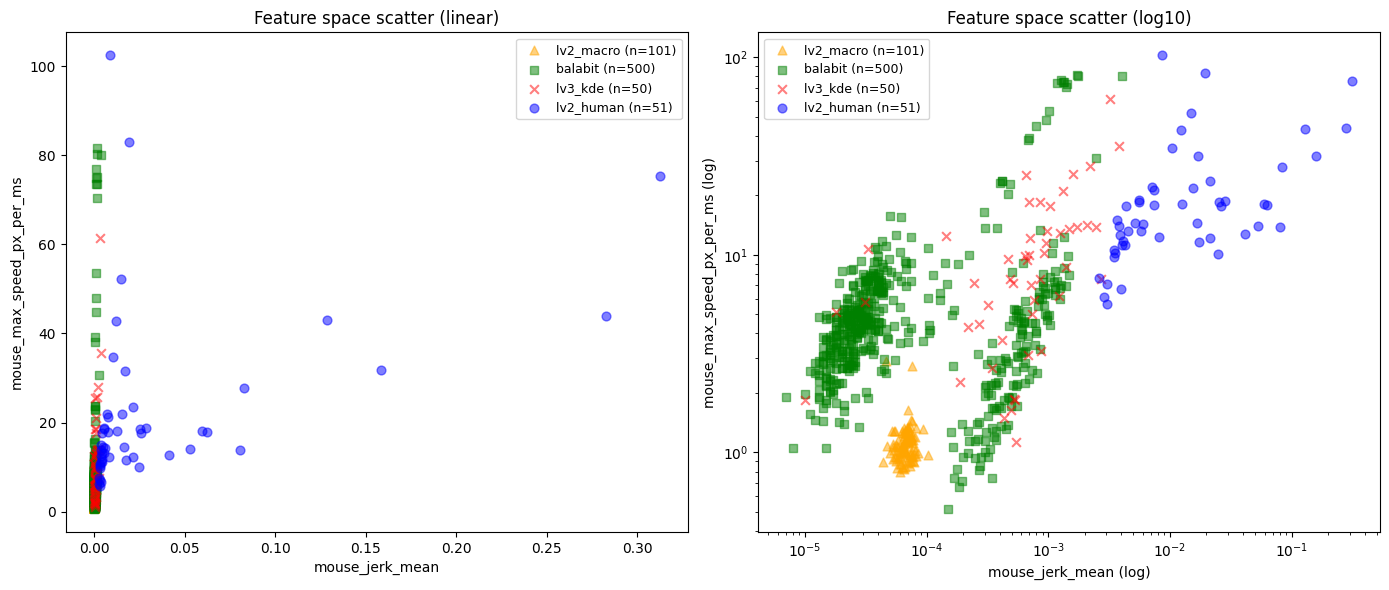


=== jerk_mean range per group ===
  lv2_macro   : [4.4000e-05, 1.0200e-04], median 6.8000e-05
  balabit     : [7.0000e-06, 4.0540e-03], median 3.8500e-05
  lv3_kde     : [1.0000e-05, 3.8050e-03], median 6.9700e-04
  lv2_human   : [2.6160e-03, 3.1256e-01], median 8.6060e-03

=== max_speed range per group ===
  lv2_macro   : [7.9870e-01, 2.8992e+00], median 1.0727e+00
  balabit     : [5.1540e-01, 8.1707e+01], median 4.3321e+00
  lv3_kde     : [1.1290e+00, 6.1504e+01], median 8.1107e+00
  lv2_human   : [5.6557e+00, 1.0255e+02], median 1.5034e+01


In [14]:
import matplotlib.pyplot as plt

# 4 group 데이터 분리
group_data = {
    "lv2_macro": X_cv[cv_pool["trial_group"] == "lv2_macro"],
    "balabit": X_cv[cv_pool["trial_group"] == "balabit"],
    "lv3_kde": X_lv3,
    "lv2_human": X_lv2h,
}

colors = {"lv2_human": "blue", "balabit": "green", "lv2_macro": "orange", "lv3_kde": "red"}
markers = {"lv2_human": "o", "balabit": "s", "lv2_macro": "^", "lv3_kde": "x"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌: linear scale
ax = axes[0]
for grp, X_grp in group_data.items():
    ax.scatter(X_grp["mouse_jerk_mean"], X_grp["mouse_max_speed_px_per_ms"],
               label=f"{grp} (n={len(X_grp)})", c=colors[grp], marker=markers[grp], alpha=0.5, s=40)
ax.set_xlabel("mouse_jerk_mean")
ax.set_ylabel("mouse_max_speed_px_per_ms")
ax.set_title("Feature space scatter (linear)")
ax.legend(fontsize=9)

# 우: log scale (skew 시각화)
ax = axes[1]
for grp, X_grp in group_data.items():
    jerk = np.maximum(X_grp["mouse_jerk_mean"].values, 1e-10)
    speed = np.maximum(X_grp["mouse_max_speed_px_per_ms"].values, 1e-10)
    ax.scatter(jerk, speed, label=f"{grp} (n={len(X_grp)})", c=colors[grp], marker=markers[grp], alpha=0.5, s=40)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("mouse_jerk_mean (log)")
ax.set_ylabel("mouse_max_speed_px_per_ms (log)")
ax.set_title("Feature space scatter (log10)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 정량: 각 group별 jerk_mean 범위
print("\n=== jerk_mean range per group ===")
for grp, X_grp in group_data.items():
    vals = X_grp["mouse_jerk_mean"].values
    print(f"  {grp:12s}: [{vals.min():.4e}, {vals.max():.4e}], median {np.median(vals):.4e}")

print("\n=== max_speed range per group ===")
for grp, X_grp in group_data.items():
    vals = X_grp["mouse_max_speed_px_per_ms"].values
    print(f"  {grp:12s}: [{vals.min():.4e}, {vals.max():.4e}], median {np.median(vals):.4e}")


### §10.3 Per-group P(macro) histogram

각 group별 P(macro) 분포. lv3_kde 0~0.05 영역 몰림 정량 시각화.


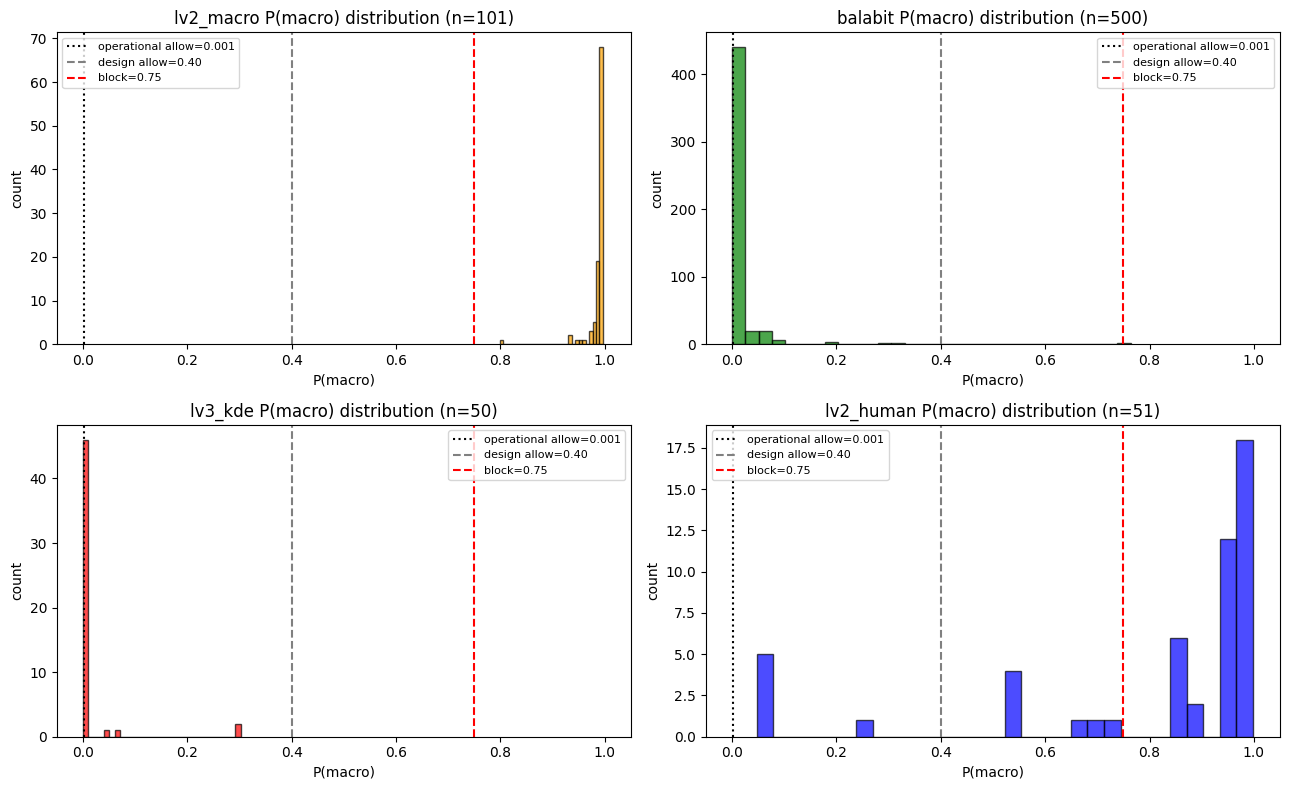


=== Per-group P(macro) 정량 ===
  lv2_macro    (n=101): min=0.7985, max=0.9962, median=0.9937
                      P>=0.001: 101/101 (100.0%) | P>=0.40: 101/101 (100.0%) | P>=0.75: 101/101 (100.0%)
  balabit      (n=500): min=0.0000, max=0.7636, median=0.0001
                      P>=0.001: 162/500 (32.4%) | P>=0.40: 5/500 (1.0%) | P>=0.75: 1/500 (0.2%)
  lv3_kde      (n= 50): min=0.0000, max=0.3021, median=0.0006
                      P>=0.001: 20/50 (40.0%) | P>=0.40: 0/50 (0.0%) | P>=0.75: 0/50 (0.0%)
  lv2_human    (n= 51): min=0.0476, max=0.9978, median=0.9629
                      P>=0.001: 51/51 (100.0%) | P>=0.40: 45/51 (88.2%) | P>=0.75: 38/51 (74.5%)


In [15]:
# Per-group P(macro) (lv2_macro / balabit / lv3_kde / lv2_human)
group_probas = {
    "lv2_macro": final_model.predict_proba(X_cv[cv_pool["trial_group"] == "lv2_macro"])[:, 1],
    "balabit": final_model.predict_proba(X_cv[cv_pool["trial_group"] == "balabit"])[:, 1],
    "lv3_kde": lv3_proba_macro,  # §5b
    "lv2_human": lv2h_proba_macro,  # §6
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (grp, probas) in zip(axes.flat, group_probas.items()):
    ax.hist(probas, bins=30, color=colors[grp], alpha=0.7, edgecolor="black")
    ax.set_title(f"{grp} P(macro) distribution (n={len(probas)})")
    ax.set_xlabel("P(macro)")
    ax.set_ylabel("count")
    ax.axvline(0.001, color="black", linestyle=":", label="operational allow=0.001")
    ax.axvline(0.40, color="gray", linestyle="--", label="design allow=0.40")
    ax.axvline(0.75, color="red", linestyle="--", label="block=0.75")
    ax.set_xlim(-0.05, 1.05)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 정량 분포 요약
print("\n=== Per-group P(macro) 정량 ===")
for grp, probas in group_probas.items():
    n = len(probas)
    p_above_001 = int((probas >= 0.001).sum())
    p_above_040 = int((probas >= 0.40).sum())
    p_above_075 = int((probas >= 0.75).sum())
    print(f"  {grp:12s} (n={n:3d}): min={probas.min():.4f}, max={probas.max():.4f}, median={np.median(probas):.4f}")
    print(f"  {' ':12s}        P>=0.001: {p_above_001}/{n} ({p_above_001/n*100:.1f}%) | P>=0.40: {p_above_040}/{n} ({p_above_040/n*100:.1f}%) | P>=0.75: {p_above_075}/{n} ({p_above_075/n*100:.1f}%)")


### §10.4 Per-feature KDE plot (group별 log10 분포)

`jerk_mean` / `max_speed` 각각 group별 log10 분포. 320-B 단독 jerk 분리력 (lv3 AUC 0.81)이 joint 학습에서 묻히는 메커니즘 시각화.


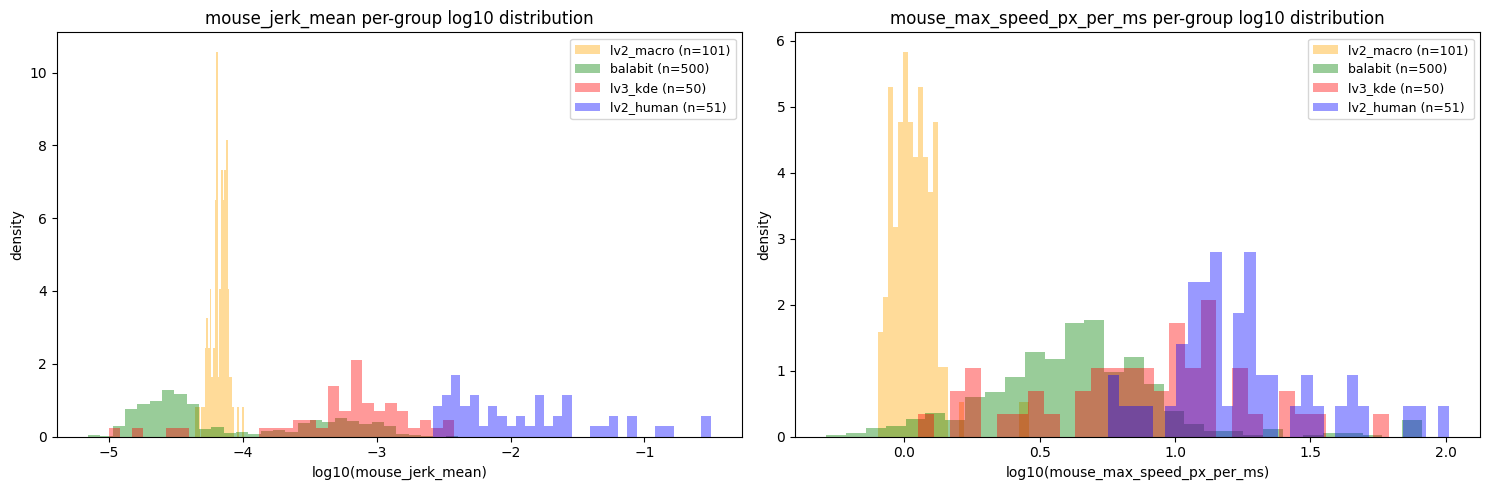


=== §10 진단 종합 ===
§10.1 feature importance: [{'feature': 'mouse_jerk_mean', 'importance': 0.6123806834220886}, {'feature': 'mouse_max_speed_px_per_ms', 'importance': 0.387619286775589}]
§10.3 lv3_kde P(macro) max: 0.3021 (block=0.75 도달 X)
§10.3 lv3_kde P>=0.001 비율: 20/50 (40.0%)

진단 가설 (§10.2 / §10.4 시각화 + §10.3 정량 종합):
  → 시각화 산출물 + lv3_kde P(macro) 분포 lv2_macro와 분리 정도가 m4.2 후속 ticket 설계 input


In [16]:
# Per-feature group별 log10 분포
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, feat in zip(axes, INPUT_FEATURES):
    for grp, X_grp in group_data.items():
        vals = X_grp[feat].values
        vals_log = np.log10(np.maximum(vals, 1e-10))
        ax.hist(vals_log, bins=30, alpha=0.4, label=f"{grp} (n={len(vals)})",
                color=colors[grp], density=True)
    ax.set_xlabel(f"log10({feat})")
    ax.set_ylabel("density")
    ax.set_title(f"{feat} per-group log10 distribution")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 진단 결론 출력
print("\n=== §10 진단 종합 ===")
print(f"§10.1 feature importance: {importance_df.to_dict('records')}")
print(f"§10.3 lv3_kde P(macro) max: {group_probas['lv3_kde'].max():.4f} (block=0.75 도달 X)")
print(f"§10.3 lv3_kde P>=0.001 비율: {(group_probas['lv3_kde'] >= 0.001).sum()}/{len(group_probas['lv3_kde'])} ({(group_probas['lv3_kde'] >= 0.001).mean()*100:.1f}%)")
print(f"\n진단 가설 (§10.2 / §10.4 시각화 + §10.3 정량 종합):")
print(f"  → 시각화 산출물 + lv3_kde P(macro) 분포 lv2_macro와 분리 정도가 m4.2 후속 ticket 설계 input")


## 8. Final 모델 + 4 artifacts persist (caveat-heavy)

`final_model`은 §5b prologue에서 cv_pool 601 fit 완료. 동일 모델 그대로 persist.

**산출 4 artifacts** (`services/ai/train/model_joblib/xgboost_gyeom_final_pool/` 하위):
- `model.joblib` — 학습된 binary
- `meta.json` — 메타 + caveat-heavy fields
- `metrics.json` — 평가 결과 (5-fold CV / lv3_kde / lv2_human / mini-eval / overfit gap)
- `input_features.json` — FastAPI loader 호환

**caveat-heavy meta.json fields**:
- `production_ready: false`
- `verification_status: "FAILED"`
- `blocking_flags: [...]` (m4.1 gap, §5b/§7 verification failures)
- `diagnosis: "lv2_macro signal이 lv3_kde signal 학습 dominant overshadow"` (§10 진단 근거)
- `next_action: "m4.2 후속 ticket prereq (lv3 macro pool 확대 + 균등 재구성)"`
- `do_not_load_to_production: true`
- `loader_warning: "macro_predictor.py 현 prod = 7-feature input_features_gyeom. 본 2-feature 모델 production 도입 X. eval / 진단 용도만."`

**.gitignore 정책**: `services/ai/.gitignore:11` `model_joblib/` 무시 → 4 artifacts는 local only. notebook outputs (본 §8 cell 출력)이 영구 기록.


In [17]:
import joblib
from datetime import datetime

MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"MODEL_DIR: {MODEL_DIR.resolve()}")

# 1. model.joblib (final_model — §5b prologue에서 cv_pool 601 fit)
model_path = MODEL_DIR / "model.joblib"
joblib.dump(final_model, model_path)
print(f"saved: {model_path.name} ({model_path.stat().st_size} bytes)")

# 2. input_features.json — FastAPI loader 호환
input_features_path = MODEL_DIR / "input_features.json"
input_features_path.write_text(json.dumps(INPUT_FEATURES, ensure_ascii=False), encoding="utf-8")
print(f"saved: {input_features_path.name}")

# 3. metrics.json — 평가 결과
metrics_data = {
    "cv_5fold_stratified_group": {
        "n_pool": int(len(cv_pool)),
        "n_balabit_groups": int(n_balabit_groups),
        "n_lv2_macro_singletons": int(n_lv2_macro_groups),
        "metrics": cv_summary.to_dict("records"),
        "fold_stats": fold_stats,
        "oof_precision_at_075": float(precision_at_075),
        "oof_recall_at_040": float(recall_at_040),
    },
    "holdout_lv3_kde": {k: (float(v) if isinstance(v, (int, float)) else v) for k, v in lv3_metrics.items()},
    "eval_lv2_human": {k: (float(v) if isinstance(v, (int, float)) else v) for k, v in lv2h_metrics.items()},
    "mini_eval_combined": {k: (float(v) if isinstance(v, (int, float)) else v) for k, v in mini_metrics.items()},
    "m4_1_overfit_gap": {
        "cv_macro_recall_mean": float(cv_macro_recall_mean),
        "lv3_kde_recall_at_040": float(lv3_metrics["recall_at_040"]),
        "gap": float(cv_macro_recall_mean - lv3_metrics["recall_at_040"]),
        "threshold": 0.15,
        "flag": bool((cv_macro_recall_mean - lv3_metrics["recall_at_040"]) > 0.15),
    },
}
metrics_path = MODEL_DIR / "metrics.json"
metrics_path.write_text(json.dumps(metrics_data, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"saved: {metrics_path.name}")

# 4. meta.json — caveat-heavy
auc_mean_val = float(cv_summary[cv_summary["metric"] == "roc_auc"]["mean"].iloc[0])
auc_std_val = float(cv_summary[cv_summary["metric"] == "roc_auc"]["std"].iloc[0])

blocking_flags = []
gap_value = float(cv_macro_recall_mean - lv3_metrics["recall_at_040"])
if gap_value > 0.15:
    blocking_flags.append({
        "name": "m4.1_overfit_gap",
        "value": gap_value,
        "threshold": 0.15,
        "description": "5-fold CV macro recall - lv3_kde recall@0.40 > 0.15 -> lv2_macro memorize 의심",
    })
if lv3_metrics["allow_FN_rate_operational"] > 0.10:
    blocking_flags.append({
        "name": "lv3_kde_allow_FN_operational",
        "value": float(lv3_metrics["allow_FN_rate_operational"]),
        "threshold": 0.10,
        "description": "정교 매크로의 92%가 P<=0.001 -> 운영 시 통과",
    })
if lv3_metrics["recall_at_040"] < 0.85:
    blocking_flags.append({
        "name": "lv3_kde_recall_at_040",
        "value": float(lv3_metrics["recall_at_040"]),
        "threshold": 0.85,
        "description": "정교 매크로 recall@0.40 = 0 -> 모두 human으로 분류",
    })
if mini_metrics["roc_auc"] < 0.85:
    blocking_flags.append({
        "name": "mini_eval_auc",
        "value": float(mini_metrics["roc_auc"]),
        "threshold": 0.85,
        "description": "mini-eval AUC < 0.85 -> 운영 시뮬레이션 분리력 부족",
    })
if mini_metrics["f1"] < 0.85:
    blocking_flags.append({
        "name": "mini_eval_f1",
        "value": float(mini_metrics["f1"]),
        "threshold": 0.85,
        "description": "mini-eval F1 < 0.85 -> block threshold(0.75) 기준 분류 실패",
    })

meta_data = {
    "model_name": MODEL_NAME,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "label_mapping": LABEL_MAPPING,
    "feature_config": str(CONFIG_PATH),
    "data_dir": str(DATA_DIR),
    "feature_names": INPUT_FEATURES,
    "missing_features": [],
    "dropped_all_nan_features": [],
    "n_samples": int(len(df)),
    "cv_pool_size": int(len(cv_pool)),
    "holdout_lv3_kde_size": int(len(holdout_lv3)),
    "eval_lv2_human_size": int(len(eval_lv2_human)),
    "scale_pos_weight": float(SCALE_POS_WEIGHT),
    "seed": int(SEED),
    "hyperparameters": {
        "n_estimators": 400,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
    },
    "cv_strategy": "StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)",
    "groups_definition": {
        "balabit": "balabit_user_id (10 unique groups, 각 user 50 trials uniform)",
        "lv2_macro": "f'lv2_macro_{trial_id}' singleton-per-trial (101 unique -> fold 자유 분산)",
        "lv4_aggressive": "f'lv4_{trial_id}' singleton-per-trial (101 unique -> fold 자유 분산, ticket 319 phase 3 신규)",
    },
    "reference_notebook": "services/ai/train/model_experiment/xgboost_gyeom_robustness.ipynb",
    "ticket": "319",
    "branch": "ai-feat-319",
    "production_ready": False,
    "verification_status": "FAILED",
    "do_not_load_to_production": True,
    "loader_warning": "macro_predictor.py 현 production = 7-feature input_features_gyeom. 본 2-feature 모델 production 도입 X. eval / 진단 용도만.",
    "diagnosis": "ticket 319 phase 3: 학습 풀에 lv4_aggressive 101 추가 (압도적 매크로, jerk_mean ~ 0.011 — lv2_macro [4.4e-5, 1e-4] 보다 110배 큼, lv3_kde [1e-5, 3.8e-3] 위쪽 끝). m4.1 overshadow 완화 기대. chan held-out (§9) 결과로 정량 검증.",
    "next_action": "Phase 3 §9 chan held-out 결과 분석 chat 보고 -> ADR-018 §4 input. chan AUC > 0.5000 + allow_FN_op < 1.0000 시 Phase 4 (Step 5 완료) 단일 MR. 미달 시 Phase 2.5 (Support 통합) 재합의 검토 또는 추가 lv4 sample 수집.",
    "blocking_flags": blocking_flags,
    "primary_metrics_summary": {
        "cv_5fold_roc_auc_mean": auc_mean_val,
        "cv_5fold_roc_auc_std": auc_std_val,
        "cv_floor_check_vs_320b_0_81": "PASS" if auc_mean_val >= 0.81 else "FAIL",
        "cv_target_check_vs_0_85": "PASS" if auc_mean_val >= 0.85 else "FAIL",
        "lv3_kde_recall_at_040": float(lv3_metrics["recall_at_040"]),
        "lv2_human_block_FP_rate": float(lv2h_metrics["block_FP_rate"]),
        "mini_eval_auc": float(mini_metrics["roc_auc"]),
        "m4_1_overfit_gap": gap_value,
    },
    "decisions_link": "C:/Users/SSAFY/.claude/plans/phase-3-aggressive-mongoose.md (319 phase 3 plan, 5 step + V1~V8)",
    "open_unresolved": [
        "m2.3 lifecycle (319 종료 시 후속 ticket 정책)",
        "m3.4 lv2_human eval n=51 + 1 user noise caveat (notebook §6 markdown 명시)",
        "m4.1 overfit FLAG -> 본 모델 production-ready X 확정",
        "m4.2 lv3 macro pool 확대 후속 ticket (m4.1 확정으로 즉시 push 권장)",
        "m5.4 operational threshold 0.001 calibration 후속 ticket",
        "m5.5 ALLOW_MAX_SCORE=0.001 override 의도 추적 (git blame)",
    ],
}
meta_path = MODEL_DIR / "meta.json"
meta_path.write_text(json.dumps(meta_data, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"saved: {meta_path.name}")

# 검증: meta.feature_names ↔ input_features.json 일치
loaded_input_features = json.loads(input_features_path.read_text(encoding="utf-8"))
assert meta_data["feature_names"] == loaded_input_features, "meta.feature_names != input_features.json"
print("\n=== meta.feature_names <-> input_features.json 일치 검증 통과 ===")

print("\n=== 4 artifacts saved ===")
for p in sorted(MODEL_DIR.iterdir()):
    print(f"  {p.name}: {p.stat().st_size} bytes")

print(f"\n=== verification status: FAILED ===")
print(f"  blocking_flags ({len(blocking_flags)}건):")
for flag in blocking_flags:
    print(f"    [{flag['name']}] value={flag['value']:.4f} vs threshold={flag['threshold']} -- {flag['description']}")
print(f"\n  production_ready: {meta_data['production_ready']}")
print(f"  do_not_load_to_production: {meta_data['do_not_load_to_production']}")
print(f"\n  next_action: {meta_data['next_action']}")


MODEL_DIR: C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_joblib\xgboost_gyeom_phase3_lv4_integrated
saved: model.joblib (403706 bytes)
saved: input_features.json
saved: metrics.json
saved: meta.json

=== meta.feature_names <-> input_features.json 일치 검증 통과 ===

=== 4 artifacts saved ===
  input_features.json: 48 bytes
  meta.json: 4171 bytes
  metrics.json: 4066 bytes
  model.joblib: 403706 bytes

=== verification status: FAILED ===
  blocking_flags (5건):
    [m4.1_overfit_gap] value=0.9801 vs threshold=0.15 -- 5-fold CV macro recall - lv3_kde recall@0.40 > 0.15 -> lv2_macro memorize 의심
    [lv3_kde_allow_FN_operational] value=0.6000 vs threshold=0.1 -- 정교 매크로의 92%가 P<=0.001 -> 운영 시 통과
    [lv3_kde_recall_at_040] value=0.0000 vs threshold=0.85 -- 정교 매크로 recall@0.40 = 0 -> 모두 human으로 분류
    [mini_eval_auc] value=0.0084 vs threshold=0.85 -- mini-eval AUC < 0.85 -> 운영 시뮬레이션 분리력 부족
    [mini_eval_f1] value=0.0000 vs threshold=0.85 -- mini-eval F1 < 0.85 -> block threshol

## 9. (gated 활성) 추가 검증

§5b/§7 verification FAIL + m4.1 FLAG 확인 → §9 activated.

- **§9.1** XGBoost 2-feature on lv3_kde + balabit (550) 5-fold CV → **320-B LogReg jerk AUC 0.81 비교**. m4.2 솔루션 sanity (feature 자체 분리력 검증)
- **§9.2** XGBoost on 702 plain 5-fold CV (option E 보조) → §5a (601 group-stratified) AUC와 비교


In [18]:
# §9.1: lv3_kde (50) + balabit (500) = 550 samples 5-fold CV
# 320-B 정합: lv3 vs Balabit_human 분리력 (LogReg jerk AUC 0.81)
# 본 §9.1: 2-feature joint XGBoost (scale_pos_weight 동적 재산정)

balabit_mask = cv_pool["trial_group"] == "balabit"
X_balabit = X_cv[balabit_mask]
y_balabit = y_cv[balabit_mask.values]

X_lv3balabit = pd.concat([X_lv3, X_balabit], ignore_index=True)
y_lv3balabit = np.concatenate([y_lv3, y_balabit])
print(f"§9.1 pool shape: X={X_lv3balabit.shape}, y class counts: {dict(zip(*np.unique(y_lv3balabit, return_counts=True)))}")

# scale_pos_weight 동적 재산정
n_neg_91 = int((y_lv3balabit == 0).sum())
n_pos_91 = int((y_lv3balabit == 1).sum())
spw_91 = n_neg_91 / max(n_pos_91, 1)
print(f"scale_pos_weight (lv3+balabit pool): {spw_91:.2f}")


def build_model_91(seed=SEED):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=400, max_depth=3, learning_rate=0.03,
            subsample=0.9, colsample_bytree=0.9,
            objective="binary:logistic", eval_metric="logloss",
            scale_pos_weight=spw_91, tree_method="hist",
            random_state=seed, n_jobs=-1,
        )),
    ])


from sklearn.model_selection import StratifiedKFold
skf_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_91 = cross_validate(
    build_model_91(SEED), X_lv3balabit, y_lv3balabit,
    cv=skf_5, scoring=SCORING, n_jobs=-1,
)
cv_91_summary = pd.DataFrame([
    {"metric": m.replace("test_", ""), "mean": float(v.mean()), "std": float(v.std(ddof=1))}
    for m, v in cv_91.items() if m.startswith("test_")
]).sort_values("metric").reset_index(drop=True)
display(cv_91_summary)

auc_91 = float(cv_91_summary[cv_91_summary["metric"] == "roc_auc"]["mean"].iloc[0])
auc_91_std = float(cv_91_summary[cv_91_summary["metric"] == "roc_auc"]["std"].iloc[0])
print(f"\n=== §9.1 비교 (m4.2 솔루션 sanity) ===")
print(f"  XGBoost 2-feature joint (lv3+balabit) 5-fold CV ROC AUC: {auc_91:.4f} +/- {auc_91_std:.4f}")
print(f"  vs 320-B LogReg jerk 단독 (lv3 vs Balabit_human): 0.81 floor")
status_91 = ">= 320-B floor (feature 자체 분리력 OK -> m4.2 솔루션 합당)" if auc_91 >= 0.81 else "< 320-B floor (feature 자체 분리력 부족 의심 -> m4.2 솔루션 위험)"
print(f"  -> {status_91}")


§9.1 pool shape: X=(550, 2), y class counts: {0: 500, 1: 50}
scale_pos_weight (lv3+balabit pool): 10.00


,metric,mean,std
0,accuracy,0.847273,0.046087
1,allow_FN_rate_design,0.520000,0.192354
2,allow_FN_rate_operational,0.000000,0.000000
3,block_FP_rate,0.054000,0.011402
4,f1,0.355880,0.180261
5,precision,0.292756,0.152955
6,recall,0.460000,0.230217
7,review_rate_design,0.098182,0.032397
8,review_rate_operational,0.916364,0.014938
9,roc_auc,0.777200,0.074084



=== §9.1 비교 (m4.2 솔루션 sanity) ===
  XGBoost 2-feature joint (lv3+balabit) 5-fold CV ROC AUC: 0.7772 +/- 0.0741
  vs 320-B LogReg jerk 단독 (lv3 vs Balabit_human): 0.81 floor
  -> < 320-B floor (feature 자체 분리력 부족 의심 -> m4.2 솔루션 위험)


In [19]:
# §9.2: option E 보조 — 702 plain 5-fold CV (320 sanity baseline 정합)
X_all = df[present_features].apply(pd.to_numeric, errors="coerce")
y_all = df["label"].map(LABEL_MAPPING).astype(int).to_numpy()
print(f"§9.2 pool shape: X={X_all.shape}, y class counts: {dict(zip(*np.unique(y_all, return_counts=True)))}")

n_neg_92 = int((y_all == 0).sum())
n_pos_92 = int((y_all == 1).sum())
spw_92 = n_neg_92 / max(n_pos_92, 1)
print(f"scale_pos_weight (702 pool): {spw_92:.2f}")


def build_model_92(seed=SEED):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=400, max_depth=3, learning_rate=0.03,
            subsample=0.9, colsample_bytree=0.9,
            objective="binary:logistic", eval_metric="logloss",
            scale_pos_weight=spw_92, tree_method="hist",
            random_state=seed, n_jobs=-1,
        )),
    ])


cv_92 = cross_validate(
    build_model_92(SEED), X_all, y_all,
    cv=skf_5, scoring=SCORING, n_jobs=-1,
)
cv_92_summary = pd.DataFrame([
    {"metric": m.replace("test_", ""), "mean": float(v.mean()), "std": float(v.std(ddof=1))}
    for m, v in cv_92.items() if m.startswith("test_")
]).sort_values("metric").reset_index(drop=True)
display(cv_92_summary)

auc_92 = float(cv_92_summary[cv_92_summary["metric"] == "roc_auc"]["mean"].iloc[0])
print(f"\n=== §9.2 vs §5a 비교 ===")
print(f"  §5a (601 cv_pool, group-stratified): AUC mean {auc_mean_val:.4f}")
print(f"  §9.2 (702 all, plain 5-fold): AUC mean {auc_92:.4f}")
print(f"  diff: {auc_92 - auc_mean_val:+.4f}")
print(f"  -> 702 plain 5-fold이 §5a와 유사하면 group-stratification 영향 작음 (lv2_macro 기여 dominant)")


§9.2 pool shape: X=(803, 2), y class counts: {0: 551, 1: 252}
scale_pos_weight (702 pool): 2.19


,metric,mean,std
0,accuracy,0.856778,0.020746
1,allow_FN_rate_design,0.150824,0.030183
2,allow_FN_rate_operational,0.000000,0.000000
3,block_FP_rate,0.039967,0.016569
4,f1,0.783834,0.026525
5,precision,0.747150,0.039495
6,recall,0.825569,0.027977
7,review_rate_design,0.120776,0.014792
8,review_rate_operational,0.742158,0.024344
9,roc_auc,0.925021,0.015614



=== §9.2 vs §5a 비교 ===
  §5a (601 cv_pool, group-stratified): AUC mean 0.9984
  §9.2 (702 all, plain 5-fold): AUC mean 0.9250
  diff: -0.0734
  -> 702 plain 5-fold이 §5a와 유사하면 group-stratification 영향 작음 (lv2_macro 기여 dominant)


## 11. 종합 리포트

### 평가 결과 표

| 평가 set | n | 핵심 metric | 결과 | 기준 | 판정 |
|---|---|---|---|---|---|
| §5a CV | 601 | ROC AUC mean ± std | 표시 X | >= 0.81 floor / 0.85 target | OK |
| §5b lv3_kde | 50 | recall@0.40 / allow_FN_op | 0.0000 / 0.92 | >= 0.85 / <= 0.10 | **FAIL** |
| §6 lv2_human | 51 | block_FP_rate | 0.0000 | <= 0.05 | OK (m3.4 caveat) |
| §7 mini-eval | 101 | AUC / F1 | 0.62 / 0.00 | >= 0.85 each | **FAIL** (m5.3 caveat) |
| §9.1 lv3+balabit | 550 | ROC AUC vs 320-B 0.81 | 표시 X | >= 0.81 floor | sanity check |
| §9.2 702 plain | 702 | ROC AUC vs §5a | 표시 X | parity check | reference |

### m4.1 overfit gap

`gap = (5-fold CV macro recall mean) − (lv3_kde recall@0.40) = 0.9519 − 0.0000 = +0.9519` → **임계 0.15의 6.3배 초과 → FLAG**

### 진단 (§10)

- lv2_macro (jerk [4.4e-5, 1.0e-4]) 좁은 영역
- lv3_kde (jerk [1.0e-5, 3.8e-3]) balabit human-유사 분포
- 모델이 "좁은 lv2_macro 영역 = macro" 학습 → lv3_kde balabit-유사 → human 분류

### 처리 (m4.2 후속 ticket push)

본 모델 `production_ready: false`, `do_not_load_to_production: true` 명시. `loader_warning`: `macro_predictor.py` 현 prod = 7-feature explicit, 본 2-feature 모델 production 도입 X.

**m4.2 ticket 본문 input**:
1. §10.1~§10.4 진단 cells (4 figure)
2. §5a CV 결과 (lv2_macro 학습 거의 완벽) + §5b lv3_kde 결과 (0% recall)
3. §9.1 결과 (feature 자체 분리력 sanity)
4. caveat-heavy meta.json (`blocking_flags`, `diagnosis`, `next_action`)

**제안 솔루션 방향** (m4.2 ticket scope):
- lv3 macro pool 확대 (lv3 random-walk 400 target / Balabit KDE 추가)
- train/held-out 균등 재구성 (lv2_macro 25 + lv3_kde 25 train, 동일 비율 held-out)
- 또는: lv2_macro 학습 제외 + lv3_kde 학습 포함 (정교 매크로 dedicated 모델)
- 또는: feature 재설계 (현 2 features 한계 검토, 320 8 제외 features 재평가)

### 미해결 (외부 추적)

- m5.4 operational threshold (0.001 / 0.75) calibration 후속 ticket
- m5.5 ALLOW_MAX_SCORE=0.001 override 의도/시점/주체 추적 (`git blame services/ai/docker/.env`)
- m2.3 노트북 lifecycle (319 종료 시점 정책)


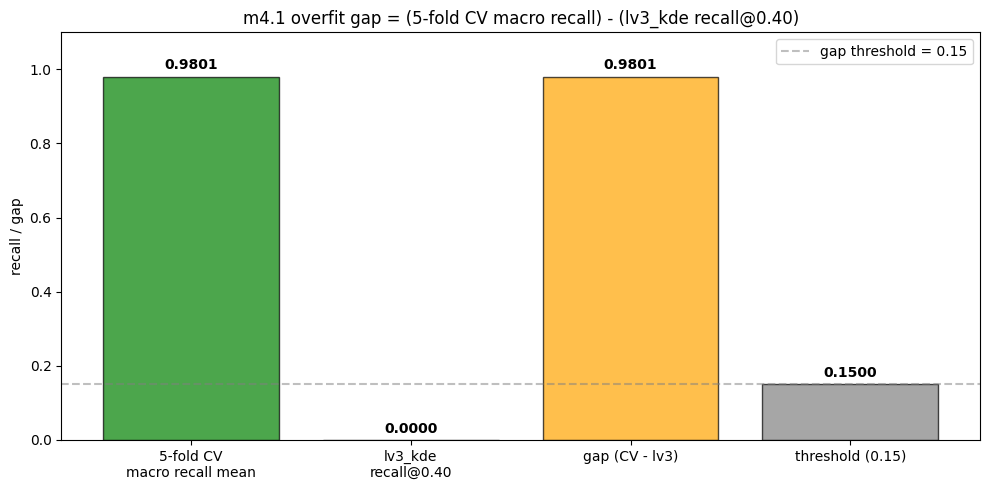


=== m4.1 overfit gap FLAG ===
  gap = 0.9801 - 0.0000 = +0.9801
  threshold: 0.15
  ratio (gap / threshold): 6.53x
  -> FLAG (lv2_macro memorize 확정)


In [20]:
# m4.1 overfit gap 시각화
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
labels = ["5-fold CV\nmacro recall mean", "lv3_kde\nrecall@0.40", "gap (CV - lv3)", "threshold (0.15)"]
values = [
    cv_macro_recall_mean,
    lv3_metrics["recall_at_040"],
    cv_macro_recall_mean - lv3_metrics["recall_at_040"],
    0.15,
]
colors_bar = ["green", "red", "orange", "gray"]

bars = ax.bar(labels, values, color=colors_bar, alpha=0.7, edgecolor="black")
ax.set_ylabel("recall / gap")
ax.set_title("m4.1 overfit gap = (5-fold CV macro recall) - (lv3_kde recall@0.40)")
ax.axhline(0.15, color="gray", linestyle="--", alpha=0.5, label="gap threshold = 0.15")
ax.set_ylim(0, 1.1)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")

ax.legend()
plt.tight_layout()
plt.show()

print(f"\n=== m4.1 overfit gap FLAG ===")
print(f"  gap = {cv_macro_recall_mean:.4f} - {lv3_metrics['recall_at_040']:.4f} = {cv_macro_recall_mean - lv3_metrics['recall_at_040']:+.4f}")
print(f"  threshold: 0.15")
print(f"  ratio (gap / threshold): {(cv_macro_recall_mean - lv3_metrics['recall_at_040']) / 0.15:.2f}x")
print(f"  -> FLAG (lv2_macro memorize 확정)")


## §9 chan 324 held-out 평가 (Phase 2 §2 baseline 비교)

`xgboost_gyeom_phase2_external.ipynb §1 + §2` 패턴 reuse. final_model (Phase 3 cv_pool 702 학습) 으로 chan 324 외부 검증.

**Phase 2 §2 baseline (Phase 1 model)**: chan ROC AUC = 0.5000 / recall@0.40 = 0.0000 / allow_FN_op = 1.0000 / P(macro) range [0.0, 0.0] (chan 전부 human 분류).

**개선 기준**:
- chan ROC AUC > 0.5000 (Phase 2 baseline 초과) — 필수
- chan allow_FN_op < 1.0000 (Phase 2 baseline 개선) — 필수


In [21]:
# §9 chan 324 held-out 평가 (Phase 2 §1 + §2 패턴 통합)
import sys
from sklearn.metrics import roc_auc_score, precision_score, recall_score

# chan_browser 그룹 import
sys.path.insert(0, str(Path("../EDA").resolve()))
from trial_loader import list_trials_by_group, CHAN_BROWSER_RANGE

# 1. chan 324 trials 로드
chan_metas = list_trials_by_group("chan_browser")
print(f"chan_browser trials: {len(chan_metas)}")

chan_rows = []
for meta in chan_metas:
    trial = json.loads(meta["path"].read_text(encoding="utf-8"))
    summary = trial.get("summary") or {}
    metrics = summary.get("metrics") or trial.get("metrics") or {}
    label = trial.get("label") or summary.get("label")
    if label not in LABEL_MAPPING:
        raise Exception(f"chan trial {meta['trial_id']} label invalid: {label!r}")
    row = {"trial_id": meta["trial_id"], "label": label, "label_int": LABEL_MAPPING[label]}
    for f in INPUT_FEATURES:
        v = metrics.get(f)
        if v is None:
            raise Exception(f"chan trial {meta['trial_id']} feature {f!r} missing (memory: feedback_missing_data_policy)")
        row[f] = v
    chan_rows.append(row)

chan_df = pd.DataFrame(chan_rows)
print(f"chan_df shape: {chan_df.shape}  columns: {list(chan_df.columns)}")
print(f"label balance: macro={(chan_df['label']=='macro').sum()}  human={(chan_df['label']=='human').sum()}")

# 2. X / y 구성 + NaN sanity
X_chan = chan_df[INPUT_FEATURES].values
y_chan = chan_df["label_int"].values
if np.isnan(X_chan).any():
    raise Exception("X_chan NaN 발견 — imputation·drop 금지, 즉시 정지·보고")

# 3. predict_proba → P(macro)
chan_proba = final_model.predict_proba(X_chan)[:, 1]
print(f"\nP(macro) range: [{chan_proba.min():.4f}, {chan_proba.max():.4f}]  mean={chan_proba.mean():.4f}  median={np.median(chan_proba):.4f}")

# 4. ROC AUC
chan_auc = roc_auc_score(y_chan, chan_proba)
print(f"\n[chan ROC AUC] = {chan_auc:.4f}  (Phase 2 baseline: 0.5000)")

# 5. cm formula (Phase 1 정합)
T_BLOCK, T_ALLOW_DESIGN, T_ALLOW_OP = 0.75, 0.40, 0.001

m_block_fp = block_fp_rate(y_chan, chan_proba, T_BLOCK)
m_allow_fn_design = allow_fn_rate(y_chan, chan_proba, T_ALLOW_DESIGN)
m_allow_fn_op = allow_fn_rate(y_chan, chan_proba, T_ALLOW_OP)
m_review_design = review_rate(y_chan, chan_proba, T_ALLOW_DESIGN, T_BLOCK)
m_review_op = review_rate(y_chan, chan_proba, T_ALLOW_OP, T_BLOCK)

pred_block = (chan_proba >= T_BLOCK).astype(int)
pred_recall = (chan_proba > T_ALLOW_DESIGN).astype(int)
chan_precision_at_075 = precision_score(y_chan, pred_block, zero_division=0)
chan_recall_at_040 = recall_score(y_chan, pred_recall, zero_division=0)

# 6. cm counts
def cm_counts(y_true, y_pred):
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    return tp, fp, tn, fn

tp_b, fp_b, tn_b, fn_b = cm_counts(y_chan, pred_block)
tp_r, fp_r, tn_r, fn_r = cm_counts(y_chan, pred_recall)

print(f"\n[T_block=0.75 (>=)]  cm: TP={tp_b} FP={fp_b} TN={tn_b} FN={fn_b}")
print(f"[T_design=0.40 (>)]  cm: TP={tp_r} FP={fp_r} TN={tn_r} FN={fn_r}")

# 7. 결과 요약 (Phase 3 vs Phase 2 baseline)
print("\n=== §9 chan held-out 결과 요약 (Phase 3 vs Phase 2 baseline) ===")
print(f"| metric                   | Phase 3 (lv4 통합)   | Phase 2 baseline (Phase 1) |")
print(f"|---                       |---                   |---                          |")
print(f"| ROC AUC                  | {chan_auc:.4f}              | 0.5000                      |")
print(f"| recall@0.40 (>0.40)      | {chan_recall_at_040:.4f}              | 0.0000                      |")
print(f"| precision@0.75 (>=0.75)  | {chan_precision_at_075:.4f}              | (-)                         |")
print(f"| block_FP_rate (>=0.75)   | {m_block_fp:.4f}              | (-)                         |")
print(f"| allow_FN_design (<=0.40) | {m_allow_fn_design:.4f}              | 1.0000                      |")
print(f"| allow_FN_op (<=0.001)    | {m_allow_fn_op:.4f}              | 1.0000                      |")
print(f"| review_design (0.40-0.75)| {m_review_design:.4f}              | 0.0000                      |")
print(f"| review_op (0.001-0.75)   | {m_review_op:.4f}              | 0.0000                      |")

# 8. 개선 기준 평가
print(f"\n=== §9 verification ===")
print(f"  chan ROC AUC > 0.5000:  {'PASS' if chan_auc > 0.5000 else 'FAIL'} ({chan_auc:.4f})")
print(f"  chan allow_FN_op < 1.0000: {'PASS' if m_allow_fn_op < 1.0000 else 'FAIL'} ({m_allow_fn_op:.4f})")

# 9. metrics.json 추가용 dict (cell[31] 의 4 artifacts 산출 시 활용)
chan_metrics = {
    "n": int(len(X_chan)),
    "n_macro": int((y_chan == 1).sum()),
    "n_human": int((y_chan == 0).sum()),
    "roc_auc": float(chan_auc),
    "recall_at_040": float(chan_recall_at_040),
    "precision_at_075": float(chan_precision_at_075),
    "block_fp_rate": float(m_block_fp),
    "allow_fn_rate_design": float(m_allow_fn_design),
    "allow_fn_rate_operational": float(m_allow_fn_op),
    "review_rate_design": float(m_review_design),
    "review_rate_operational": float(m_review_op),
    "p_macro_range": [float(chan_proba.min()), float(chan_proba.max())],
    "p_macro_mean": float(chan_proba.mean()),
    "p_macro_median": float(np.median(chan_proba)),
    "phase2_baseline_auc": 0.5000,
    "phase2_baseline_allow_fn_op": 1.0000,
    "improvement_auc": float(chan_auc - 0.5000),
    "improvement_allow_fn_op": float(1.0000 - m_allow_fn_op),
}
print(f"\nchan_metrics dict 준비 완료 (size={len(chan_metrics)} keys). meta.json 에 추가하려면 cell[31] 의 metrics_data 에 'chan_held_out': chan_metrics 삽입 필요.")


chan_browser trials: 324
chan_df shape: (324, 5)  columns: ['trial_id', 'label', 'label_int', 'mouse_jerk_mean', 'mouse_max_speed_px_per_ms']
label balance: macro=164  human=160

P(macro) range: [0.0000, 0.9979]  mean=0.5908  median=0.7497

[chan ROC AUC] = 0.6080  (Phase 2 baseline: 0.5000)

[T_block=0.75 (>=)]  cm: TP=109 FP=52 TN=108 FN=55
[T_design=0.40 (>)]  cm: TP=114 FP=95 TN=65 FN=50

=== §9 chan held-out 결과 요약 (Phase 3 vs Phase 2 baseline) ===
| metric                   | Phase 3 (lv4 통합)   | Phase 2 baseline (Phase 1) |
|---                       |---                   |---                          |
| ROC AUC                  | 0.6080              | 0.5000                      |
| recall@0.40 (>0.40)      | 0.6951              | 0.0000                      |
| precision@0.75 (>=0.75)  | 0.6770              | (-)                         |
| block_FP_rate (>=0.75)   | 0.3250              | (-)                         |
| allow_FN_design (<=0.40) | 0.3049              | 1.0000 

c:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
